In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar el dataset
file_path = '../data/raw/credit_card_transactions.csv'
data = pd.read_csv(file_path)
data.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,28705.0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,NaN
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,83236.0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,NaN
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,22844.0


In [58]:
data['trans_date_trans_time'] = pd.to_datetime(data['trans_date_trans_time'])

In [59]:
eda_columns = [
    'amt', 'category', 'city_pop', 'is_fraud', 'gender', 'state',
    'lat', 'long', 'merch_lat', 'merch_long'
]

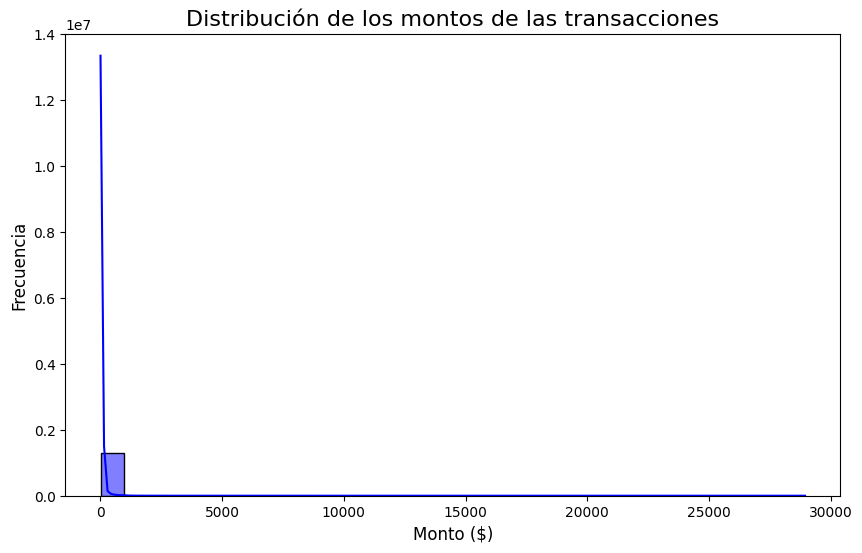

In [60]:
# 1. Distribución de los montos de las transacciones
plt.figure(figsize=(10, 6))
sns.histplot(data['amt'], bins=30, kde=True, color='blue')
plt.title('Distribución de los montos de las transacciones', fontsize=16)
plt.xlabel('Monto ($)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.show()

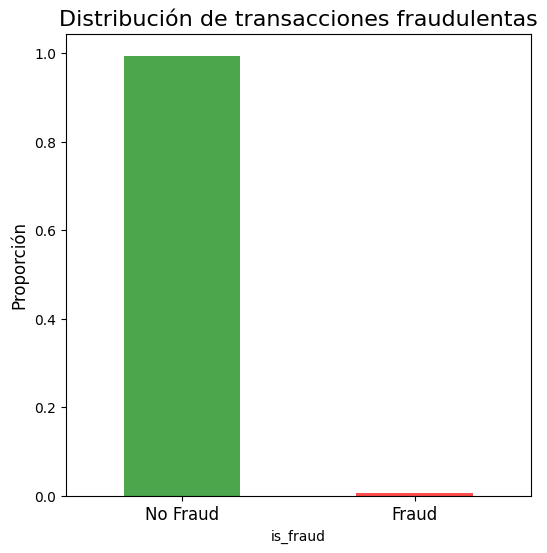

In [61]:
# 2. Distribución de las transacciones fraudulentas vs. no fraudulentas
fraud_counts = data['is_fraud'].value_counts(normalize=True)

plt.figure(figsize=(6, 6))
fraud_counts.plot(kind='bar', color=['green', 'red'], alpha=0.7)
plt.title('Distribución de transacciones fraudulentas', fontsize=16)
plt.xticks(ticks=[0, 1], labels=['No Fraud', 'Fraud'], fontsize=12, rotation=0)
plt.ylabel('Proporción', fontsize=12)
plt.show()

C:\Users\dario\AppData\Local\Temp\ipykernel_37252\2348371781.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_fraud', y='amt', data=data, palette='Set1')


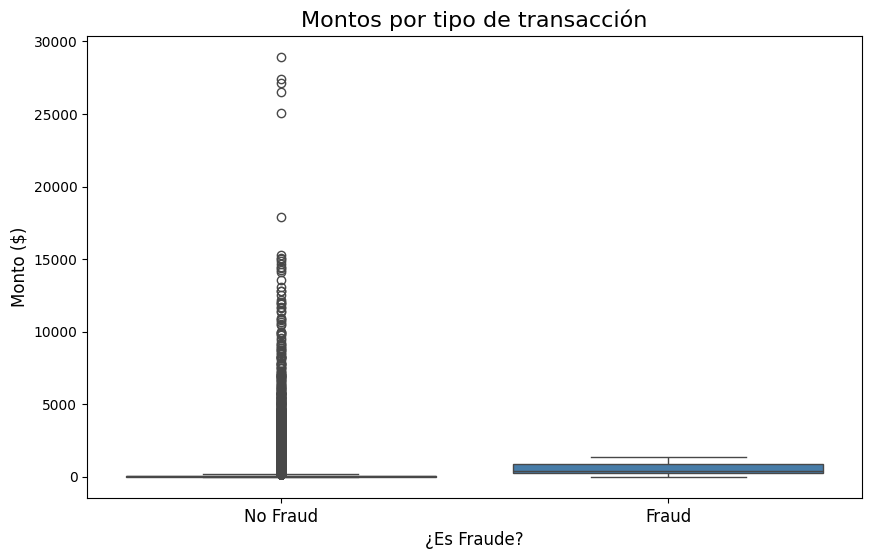

In [62]:
# 3. Análisis de montos para transacciones fraudulentas y legítimas
plt.figure(figsize=(10, 6))
sns.boxplot(x='is_fraud', y='amt', data=data, palette='Set1')
plt.title('Montos por tipo de transacción', fontsize=16)
plt.xlabel('¿Es Fraude?', fontsize=12)
plt.ylabel('Monto ($)', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['No Fraud', 'Fraud'], fontsize=12)
plt.show()

C:\Users\dario\AppData\Local\Temp\ipykernel_37252\3676309980.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='category', data=data, order=data['category'].value_counts().index, palette='viridis')


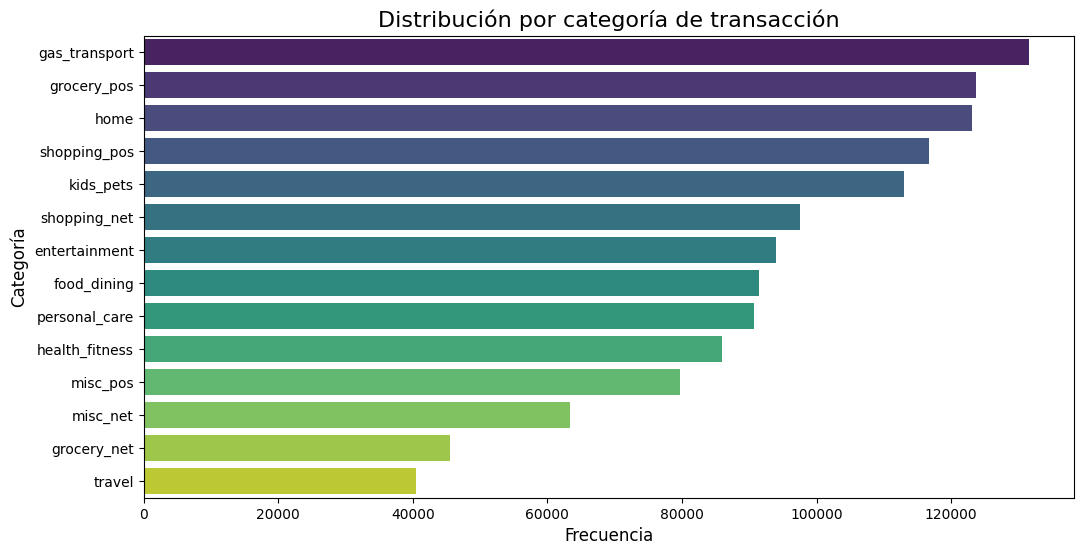

In [63]:
# 4. Distribución por categoría de transacción
plt.figure(figsize=(12, 6))
sns.countplot(y='category', data=data, order=data['category'].value_counts().index, palette='viridis')
plt.title('Distribución por categoría de transacción', fontsize=16)
plt.xlabel('Frecuencia', fontsize=12)
plt.ylabel('Categoría', fontsize=12)
plt.show()

C:\Users\dario\AppData\Local\Temp\ipykernel_37252\1705110107.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_fraud', y='city_pop', data=data, palette='coolwarm')


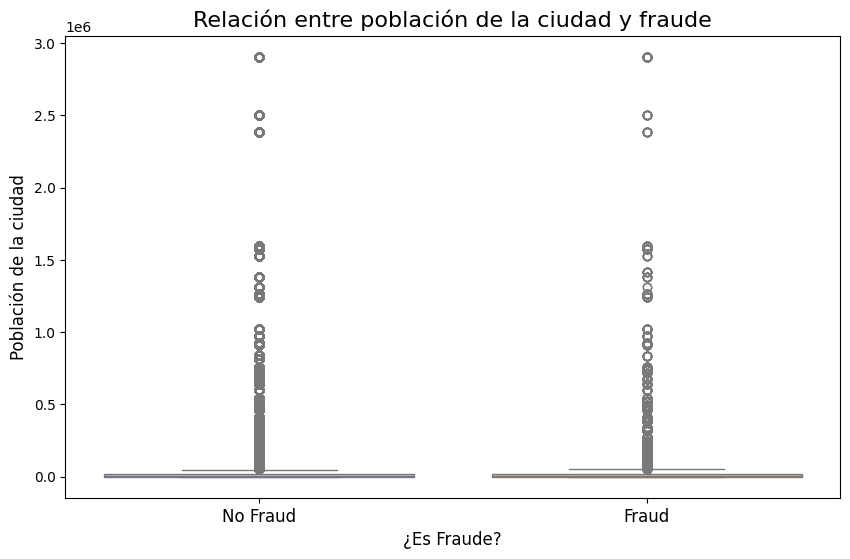

In [64]:
# 5. Relación entre la población de la ciudad y fraude
plt.figure(figsize=(10, 6))
sns.boxplot(x='is_fraud', y='city_pop', data=data, palette='coolwarm')
plt.title('Relación entre población de la ciudad y fraude', fontsize=16)
plt.xlabel('¿Es Fraude?', fontsize=12)
plt.ylabel('Población de la ciudad', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['No Fraud', 'Fraud'], fontsize=12)
plt.show()

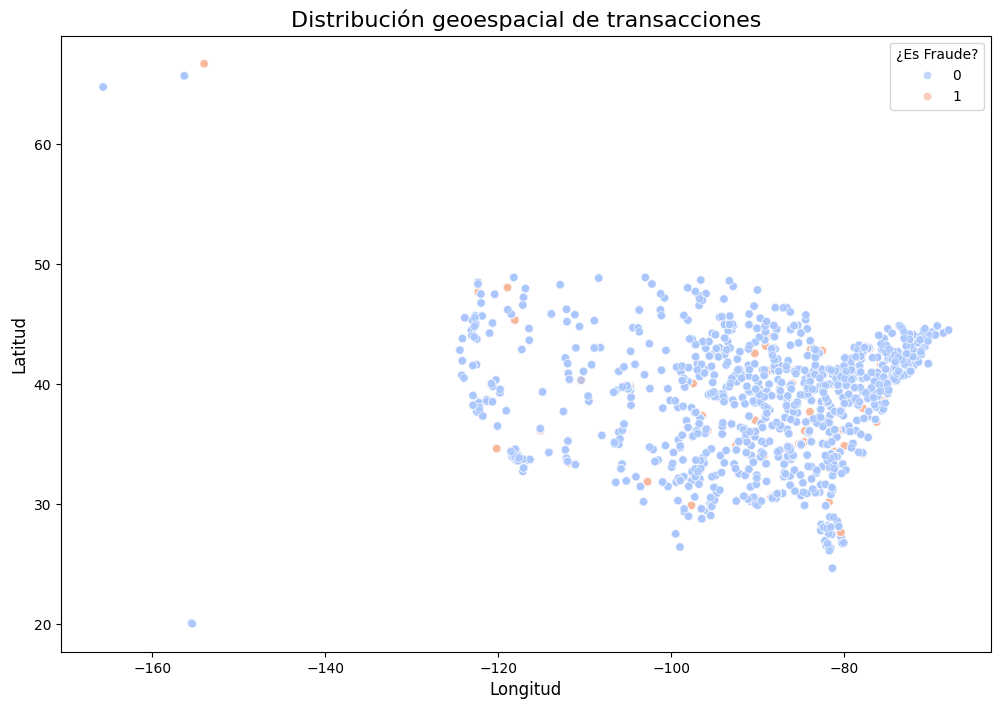

In [65]:
# 6. Análisis geoespacial (latitud y longitud)
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='long', y='lat', hue='is_fraud', data=data, palette='coolwarm', alpha=0.7
)
plt.title('Distribución geoespacial de transacciones', fontsize=16)
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)
plt.legend(title='¿Es Fraude?', loc='upper right')
plt.show()

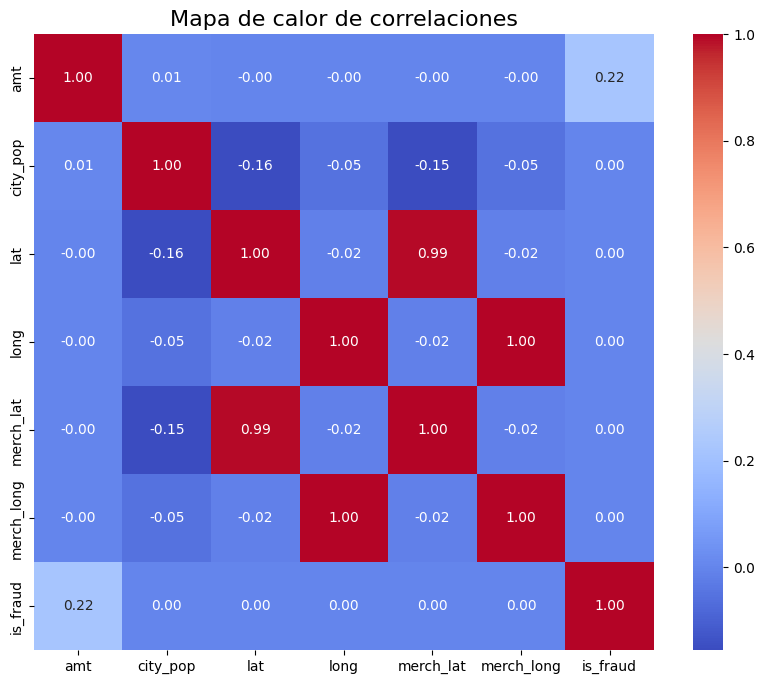

In [66]:
# 7. Análisis de correlaciones
correlation_data = data[['amt', 'city_pop', 'lat', 'long', 'merch_lat', 'merch_long', 'is_fraud']]
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_data.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Mapa de calor de correlaciones', fontsize=16)
plt.show()

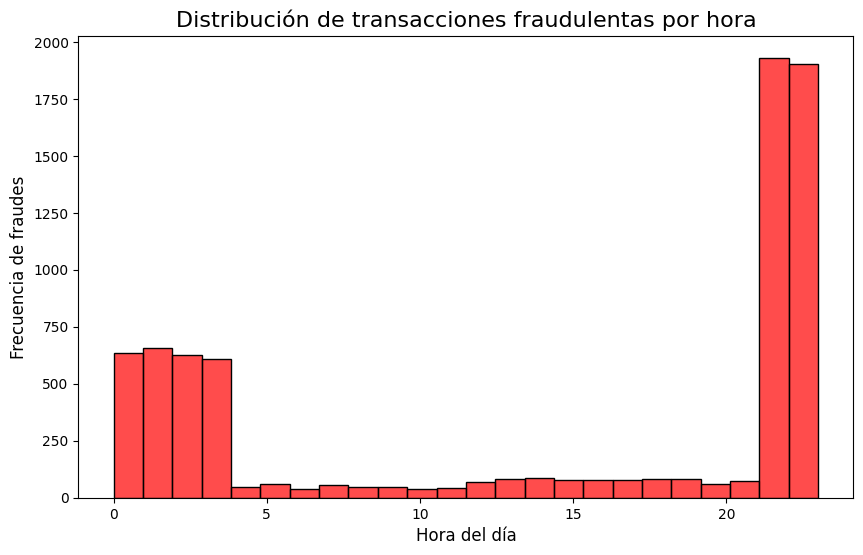

In [67]:
# 8. Distribución temporal de fraudes
plt.figure(figsize=(10, 6))
data['hour'] = data['trans_date_trans_time'].dt.hour
sns.histplot(data[data['is_fraud'] == 1]['hour'], bins=24, kde=False, color='red', alpha=0.7)
plt.title('Distribución de transacciones fraudulentas por hora', fontsize=16)
plt.xlabel('Hora del día', fontsize=12)
plt.ylabel('Frecuencia de fraudes', fontsize=12)
plt.show()

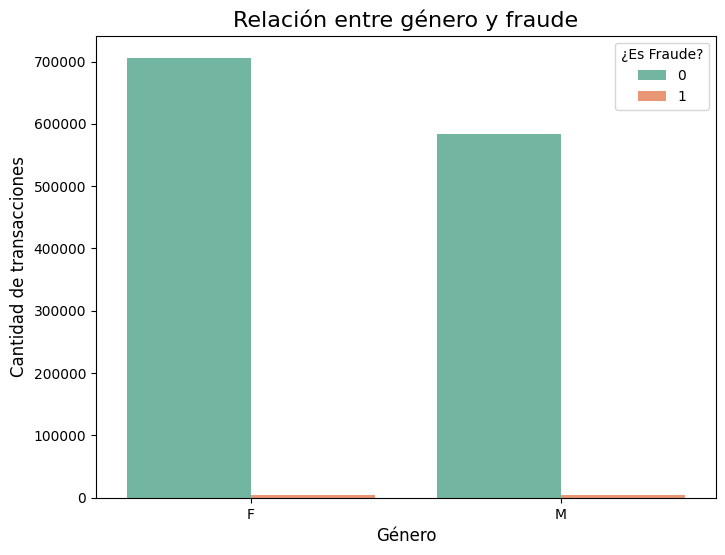

In [68]:
# 9. Relación entre género y fraude
plt.figure(figsize=(8, 6))
sns.countplot(x='gender', hue='is_fraud', data=data, palette='Set2')
plt.title('Relación entre género y fraude', fontsize=16)
plt.xlabel('Género', fontsize=12)
plt.ylabel('Cantidad de transacciones', fontsize=12)
plt.legend(title='¿Es Fraude?', loc='upper right')
plt.show()

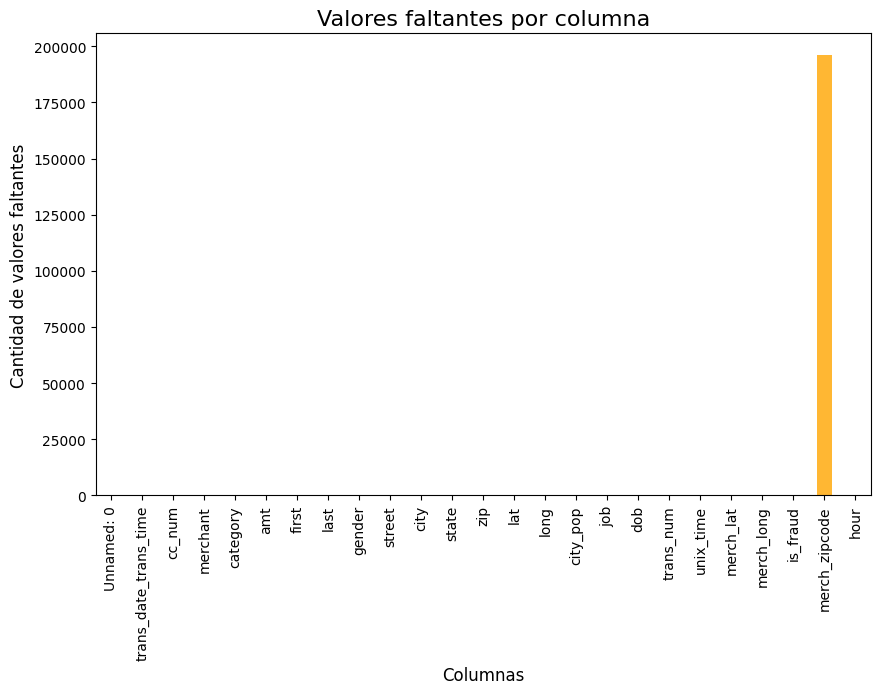

In [69]:
#Detección de valores faltantes
missing_values = data.isnull().sum()
plt.figure(figsize=(10, 6))
missing_values.plot(kind='bar', color='orange', alpha=0.8)
plt.title('Valores faltantes por columna', fontsize=16)
plt.ylabel('Cantidad de valores faltantes', fontsize=12)
plt.xlabel('Columnas', fontsize=12)
plt.show()

In [70]:
#. Detección de duplicados
duplicates_count = data.duplicated().sum()
print(f"Número de filas duplicadas: {duplicates_count}")

Número de filas duplicadas: 0


In [71]:
data_types = data.dtypes
print("Tipos de datos:")
print(data_types)

Tipos de datos:
Unnamed: 0                        int64
trans_date_trans_time    datetime64[ns]
cc_num                            int64
merchant                         object
category                         object
amt                             float64
first                            object
last                             object
gender                           object
street                           object
city                             object
state                            object
zip                               int64
lat                             float64
long                            float64
city_pop                          int64
job                              object
dob                              object
trans_num                        object
unix_time                         int64
merch_lat                       float64
merch_long                      float64
is_fraud                          int64
merch_zipcode                   float64
hour                    

In [72]:
# Revisar si las columnas categóricas contienen valores únicos inesperados
for col in ['category', 'gender', 'state']:
    unique_values = data[col].unique()
    print(f"Valores únicos en {col}: {unique_values}")

Valores únicos en category: ['misc_net' 'grocery_pos' 'entertainment' 'gas_transport' 'misc_pos'
 'grocery_net' 'shopping_net' 'shopping_pos' 'food_dining' 'personal_care'
 'health_fitness' 'travel' 'kids_pets' 'home']
Valores únicos en gender: ['F' 'M']
Valores únicos en state: ['NC' 'WA' 'ID' 'MT' 'VA' 'PA' 'KS' 'TN' 'IA' 'WV' 'FL' 'CA' 'NM' 'NJ'
 'OK' 'IN' 'MA' 'TX' 'WI' 'MI' 'WY' 'HI' 'NE' 'OR' 'LA' 'DC' 'KY' 'NY'
 'MS' 'UT' 'AL' 'AR' 'MD' 'GA' 'ME' 'AZ' 'MN' 'OH' 'CO' 'VT' 'MO' 'SC'
 'NV' 'IL' 'NH' 'SD' 'AK' 'ND' 'CT' 'RI' 'DE']


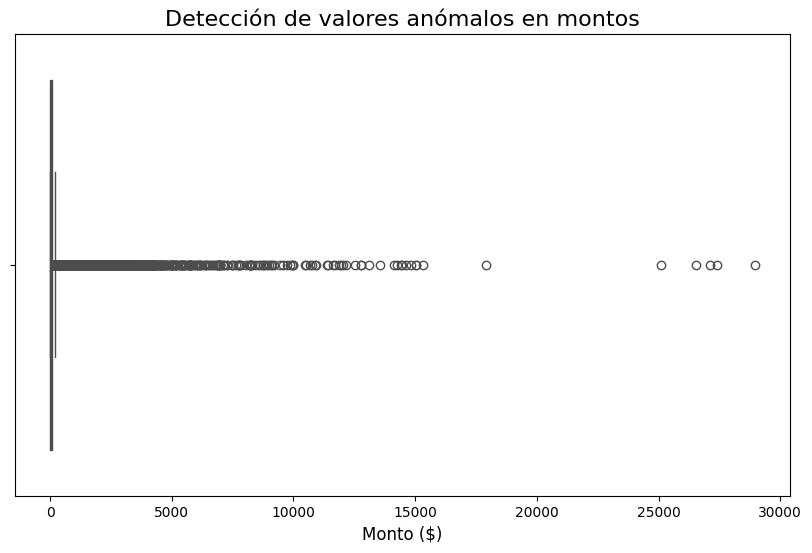

In [73]:
#Valores fuera de rango o sospechosos en variables numéricas

plt.figure(figsize=(10, 6))
sns.boxplot(data['amt'], color='red', orient='h')
plt.title('Detección de valores anómalos en montos', fontsize=16)
plt.xlabel('Monto ($)', fontsize=12)
plt.show()

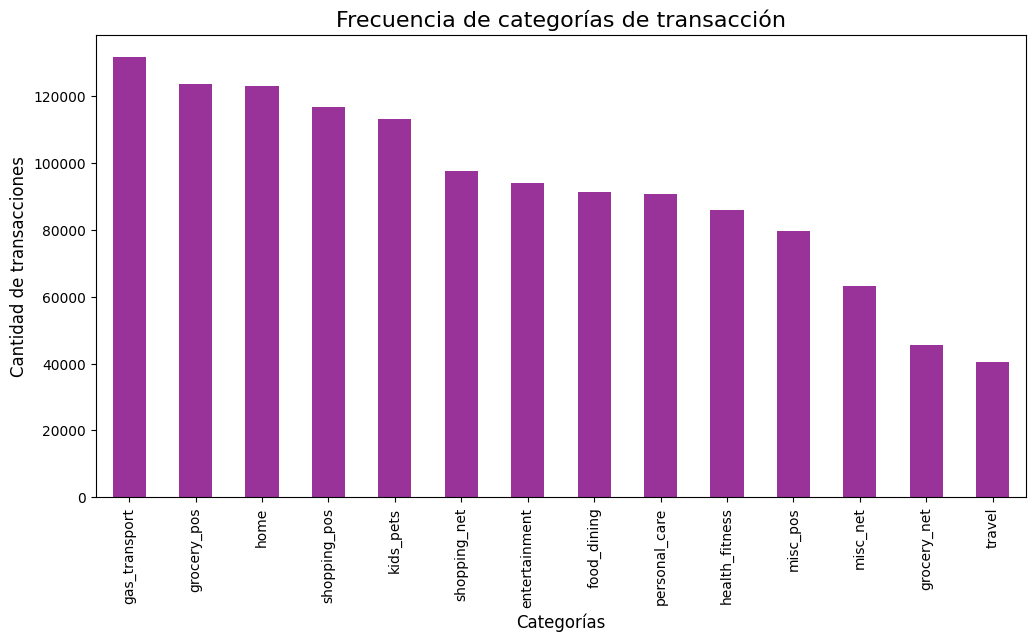

In [75]:
# 7. Chequeo de categorías con frecuencias bajas o inesperadas
category_counts = data['category'].value_counts()
plt.figure(figsize=(12, 6))
category_counts.plot(kind='bar', color='purple', alpha=0.8)
plt.title('Frecuencia de categorías de transacción', fontsize=16)
plt.ylabel('Cantidad de transacciones', fontsize=12)
plt.xlabel('Categorías', fontsize=12)
plt.show()